# Notebook 05 — NLP Avanzado con Transformers (Embeddings)

## Objetivo
Explorar si el uso de representaciones semánticas profundas (Embeddings) generadas por modelos Transformer de HuggingFace sobre las reseñas tempranas, mejora el poder predictivo del modelo en comparación con técnicas NLP tradicionales (VADER y keywords).

## Estructura
- Bloque A — Agrupación de texto por juego (T+30)
- Bloque B — Generación de Embeddings con `sentence-transformers`
- Bloque C — Integración con el dataset maestro
- Bloque D — Modelado y comparación con la línea base


# Bloque A

In [1]:
# ---------------------------------------------------------
# Bloque A: Agrupación de texto por juego
# ---------------------------------------------------------
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed/')


# Cargamos los juegos y las reseñas limpias
df_games = pd.read_parquet(PROCESSED / 'games_clean.parquet')
df_reviews = pd.read_parquet(PROCESSED / 'reviews_clean.parquet')

# 1. Recrear el filtro de los primeros 30 días
df_reviews = df_reviews.merge(df_games[['appid', 'release_date']], on='appid', how='left')
df_reviews['days_since_release'] = (df_reviews['post_date'] - df_reviews['release_date']).dt.days

df_early = df_reviews[
    (df_reviews['days_since_release'] >= 0) & 
    (df_reviews['days_since_release'] <= 30)
].copy()

# 2. Limpieza básica para el transformer (eliminar nulos o muy cortos)
df_early = df_early.dropna(subset=['review'])
df_early = df_early[df_early['review'].str.len() > 10]

# 3. Agrupar todas las reseñas de un juego en un solo bloque de texto.
# Para evitar saturar la memoria (y porque los transformers tienen un límite de tokens),
# tomaremos solo las 50 reseñas más "útiles" (helpfulness) de cada juego en esos 30 días.
df_early = df_early.sort_values(by=['appid', 'helpfulness'], ascending=[True, False])
df_top_early = df_early.groupby('appid').head(50)

# Unir el texto separándolo por punto y final
df_text_grouped = df_top_early.groupby('appid')['review'].apply(lambda x: '. '.join(x)).reset_index()

# Truncar el string final a unos 2500 caracteres (aprox 500 palabras) para velocidad
df_text_grouped['review_concat'] = df_text_grouped['review'].str.slice(0, 2500)

print(f"Juegos con texto agrupado: {len(df_text_grouped)}")
print("\nEjemplo de texto agrupado (Juego index 0):")
print(df_text_grouped['review_concat'].iloc[0][:300] + "...")


Juegos con texto agrupado: 11467

Ejemplo de texto agrupado (Juego index 0):
To old fans: if like me you were disappointed by the second game then don't worry, this third instalment brings back the sense of gradual progress from CSD 1 (upgrades that make your life easier, food categorised by kind and difficulty) while keeping the improvements from CSD 2 (holding stations, mo...


In [ ]:
# ---------------------------------------------------------
# Bloque B: Generación de Embeddings
# ---------------------------------------------------------
from sentence_transformers import SentenceTransformer
import time

print("Cargando modelo Transformer (all-MiniLM-L6-v2)...")

model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Modelo cargado. Iniciando generación de embeddings para {len(df_text_grouped)} juegos...")
start_time = time.time()

# Generar embeddings
# show_progress_bar=True nos dejará ver el progreso. 
# batch_size=32 es seguro para casi cualquier ordenador.
text_list = df_text_grouped['review_concat'].tolist()
embeddings = model.encode(text_list, batch_size=32, show_progress_bar=True)

end_time = time.time()
print(f" Embeddings generados en {(end_time - start_time)/60:.1f} minutos.")
print(f"Forma de la matriz de embeddings: {embeddings.shape}")

# Convertir a DataFrame
# Tendremos 384 columnas, las llamaremos emb_0, emb_1, ..., emb_383
emb_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
df_embeddings = pd.DataFrame(embeddings, columns=emb_cols)
df_embeddings['appid'] = df_text_grouped['appid']

print("Ejemplo de las primeras 5 dimensiones del primer juego:")
print(df_embeddings.iloc[0, :5])


Cargando modelo Transformer (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1131.66it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado. Iniciando generación de embeddings para 11467 juegos...


Batches: 100%|██████████| 359/359 [03:42<00:00,  1.61it/s]

 Embeddings generados en 3.7 minutos.
Forma de la matriz de embeddings: (11467, 384)
Ejemplo de las primeras 5 dimensiones del primer juego:
emb_0    0.008276
emb_1   -0.056599
emb_2    0.018656
emb_3    0.035867
emb_4    0.014268
Name: 0, dtype: object


In [3]:
# ---------------------------------------------------------
# Bloque C: Integración con Dataset Maestro
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

print("Cargando dataset maestro y aplicando filtros antileakage...")
df_master = pd.read_parquet(PROCESSED / 'dataset_maestro.parquet')

# Unir con embeddings
df_full = df_master.merge(df_embeddings, on='appid', how='left')

# Los juegos que no tenían texto en T+30 tendrán NaN en las columnas emb_. Rellenamos con 0.
for col in emb_cols:
    df_full[col] = df_full[col].fillna(0)

print(f"Shape tras unir embeddings: {df_full.shape}")

# Separar features (X) y target (y)
DROP_COLS = ['appid', 'release_date', 'is_successful']
X_full = df_full.drop(columns=DROP_COLS)
y_full = df_full['is_successful']

# Eliminar variables que generan data leakage (igual que en NB04)
LEAKAGE_COLS = [
    'owners_midpoint', 'peak_ccu', 'median_playtime_forever', 'csv_review_count',
    'twitch_peak_viewers', 'twitch_hours_watched', 'twitch_avg_viewers', 'twitch_months_in_top200'
]
X_full = X_full.drop(columns=LEAKAGE_COLS)

# Preprocesamiento (mismas reglas que NB04)
bool_cols = X_full.select_dtypes(include=['bool']).columns.tolist()
for col in bool_cols:
    X_full[col] = X_full[col].astype(int)

outlier_cols = ['avg_early_playtime', 'avg_early_helpfulness']
for col in outlier_cols:
    if col in X_full.columns:
        X_full[col] = np.log1p(X_full[col])

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

num_cols  = X_full.select_dtypes(include=[np.number]).columns.tolist()
scale_cols = [c for c in num_cols if c not in 
              [col for col in X_full.columns if col.startswith('genre_') 
               or col.startswith('tag_') or col in bool_cols]]

scaler = RobustScaler()
X_train_f[scale_cols] = scaler.fit_transform(X_train_f[scale_cols])
X_test_f[scale_cols]  = scaler.transform(X_test_f[scale_cols])

print(f"Dimensiones de entrenamiento (X_train): {X_train_f.shape}")



Cargando dataset maestro y aplicando filtros antileakage...
Shape tras unir embeddings: (11371, 455)
Dimensiones de entrenamiento (X_train): (9096, 444)


In [4]:
# ---------------------------------------------------------
# Bloque D: Modelado y Comparativa (Con Embeddings)
# ---------------------------------------------------------
ratio_desbalance = y_train_f.value_counts()[0] / y_train_f.value_counts()[1]

print("\nEntrenando XGBoost con hiperparámetros optimizados y Embeddings...")
# Usamos los hiperparámetros óptimos encontrados en NB04
xgb_nlp = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    gamma=0.5,
    min_child_weight=1,
    scale_pos_weight=ratio_desbalance,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_nlp.fit(X_train_f, y_train_f)

y_pred_nlp = xgb_nlp.predict(X_test_f)
y_proba_nlp = xgb_nlp.predict_proba(X_test_f)[:, 1]

roc_nlp = roc_auc_score(y_test_f, y_proba_nlp)

print("\n=== Resultados XGBoost CON Embeddings Semánticos ===")
print(f"ROC-AUC: {roc_nlp:.4f} (Línea Base en NB04: ~0.8552)")
print(classification_report(y_test_f, y_pred_nlp, target_names=['No exitoso', 'Exitoso']))



Entrenando XGBoost con hiperparámetros optimizados y Embeddings...

=== Resultados XGBoost CON Embeddings Semánticos ===
ROC-AUC: 0.8436 (Línea Base en NB04: ~0.8552)
              precision    recall  f1-score   support

  No exitoso       0.87      0.80      0.83      1615
     Exitoso       0.59      0.71      0.65       660

    accuracy                           0.77      2275
   macro avg       0.73      0.76      0.74      2275
weighted avg       0.79      0.77      0.78      2275



Como el anterior modelo, al igual que el VADER, se basan solo en textos en inglés, puede ser interesante probar un con embedding que acepte multiples lenguas y comparar su rendimiento con los otros modelos

In [5]:
# ---------------------------------------------------------
# Bloque E: Experimento Multilingüe + PCA
# ---------------------------------------------------------
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import time

print("1. Cargando modelo Transformer MULTILINGÜE...")
# Este modelo entiende reseñas en ruso, chino, español, inglés...
model_multi = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("2. Generando Embeddings Multilingües...")
start_time = time.time()
text_list = df_text_grouped['review_concat'].tolist()
embeddings_multi = model_multi.encode(text_list, batch_size=32, show_progress_bar=True)
print(f" Embeddings multilingües generados en {(time.time() - start_time)/60:.1f} minutos.")

print("3. Aplicando PCA para reducir ruido y evitar overfitting...")
# Comprimimos 384 dimensiones en 20 componentes principales concentradas
pca = PCA(n_components=20, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_multi)

# Crear DataFrame con los componentes PCA
pca_cols = [f'pca_{i}' for i in range(20)]
df_pca = pd.DataFrame(embeddings_pca, columns=pca_cols)
df_pca['appid'] = df_text_grouped['appid']

print("4. Integrando con Dataset Maestro...")
df_master = pd.read_parquet(PROCESSED / 'dataset_maestro.parquet')
df_full_pca = df_master.merge(df_pca, on='appid', how='left')

for col in pca_cols:
    df_full_pca[col] = df_full_pca[col].fillna(0)

# Preprocesamiento idéntico (quitar leakage, log transform, escalar)
X_full_pca = df_full_pca.drop(columns=DROP_COLS + LEAKAGE_COLS)
y_full_pca = df_full_pca['is_successful']

for col in bool_cols:
    X_full_pca[col] = X_full_pca[col].astype(int)

for col in outlier_cols:
    if col in X_full_pca.columns:
        X_full_pca[col] = np.log1p(X_full_pca[col])

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_full_pca, y_full_pca, test_size=0.2, random_state=42, stratify=y_full_pca
)

scale_cols_pca = [c for c in X_full_pca.select_dtypes(include=[np.number]).columns 
                  if not c.startswith(('genre_', 'tag_', 'pca_')) and c not in bool_cols]

scaler = RobustScaler()
X_train_pca[scale_cols_pca] = scaler.fit_transform(X_train_pca[scale_cols_pca])
X_test_pca[scale_cols_pca] = scaler.transform(X_test_pca[scale_cols_pca])

print(f"Dimensiones de entrenamiento X_train (PCA): {X_train_pca.shape}")

print("\n5. Entrenando XGBoost Final...")
xgb_pca = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=1.0, colsample_bytree=0.8, gamma=0.5, min_child_weight=1,
    scale_pos_weight=ratio_desbalance, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

xgb_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = xgb_pca.predict(X_test_pca)
y_proba_pca = xgb_pca.predict_proba(X_test_pca)[:, 1]
roc_pca = roc_auc_score(y_test_pca, y_proba_pca)

print("\n=== Resultados XGBoost con Embeddings Multilingües (PCA-20) ===")
print(f"ROC-AUC: {roc_pca:.4f} (Línea Base: ~0.8552 | Emb. Inglés puros: 0.8436)")
print(classification_report(y_test_pca, y_pred_pca, target_names=['No exitoso', 'Exitoso']))


1. Cargando modelo Transformer MULTILINGÜE...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 959.38it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


2. Generando Embeddings Multilingües...


Batches: 100%|██████████| 359/359 [03:20<00:00,  1.79it/s]


 Embeddings multilingües generados en 3.4 minutos.
3. Aplicando PCA para reducir ruido y evitar overfitting...
4. Integrando con Dataset Maestro...
Dimensiones de entrenamiento X_train (PCA): (9096, 80)

5. Entrenando XGBoost Final...

=== Resultados XGBoost con Embeddings Multilingües (PCA-20) ===
ROC-AUC: 0.8549 (Línea Base: ~0.8552 | Emb. Inglés puros: 0.8436)
              precision    recall  f1-score   support

  No exitoso       0.89      0.79      0.83      1615
     Exitoso       0.59      0.75      0.66       660

    accuracy                           0.78      2275
   macro avg       0.74      0.77      0.75      2275
weighted avg       0.80      0.78      0.78      2275



 Dashboard guardado exitosamente en: ..\data\processed\xgb_nlp_advanced_dashboard.png


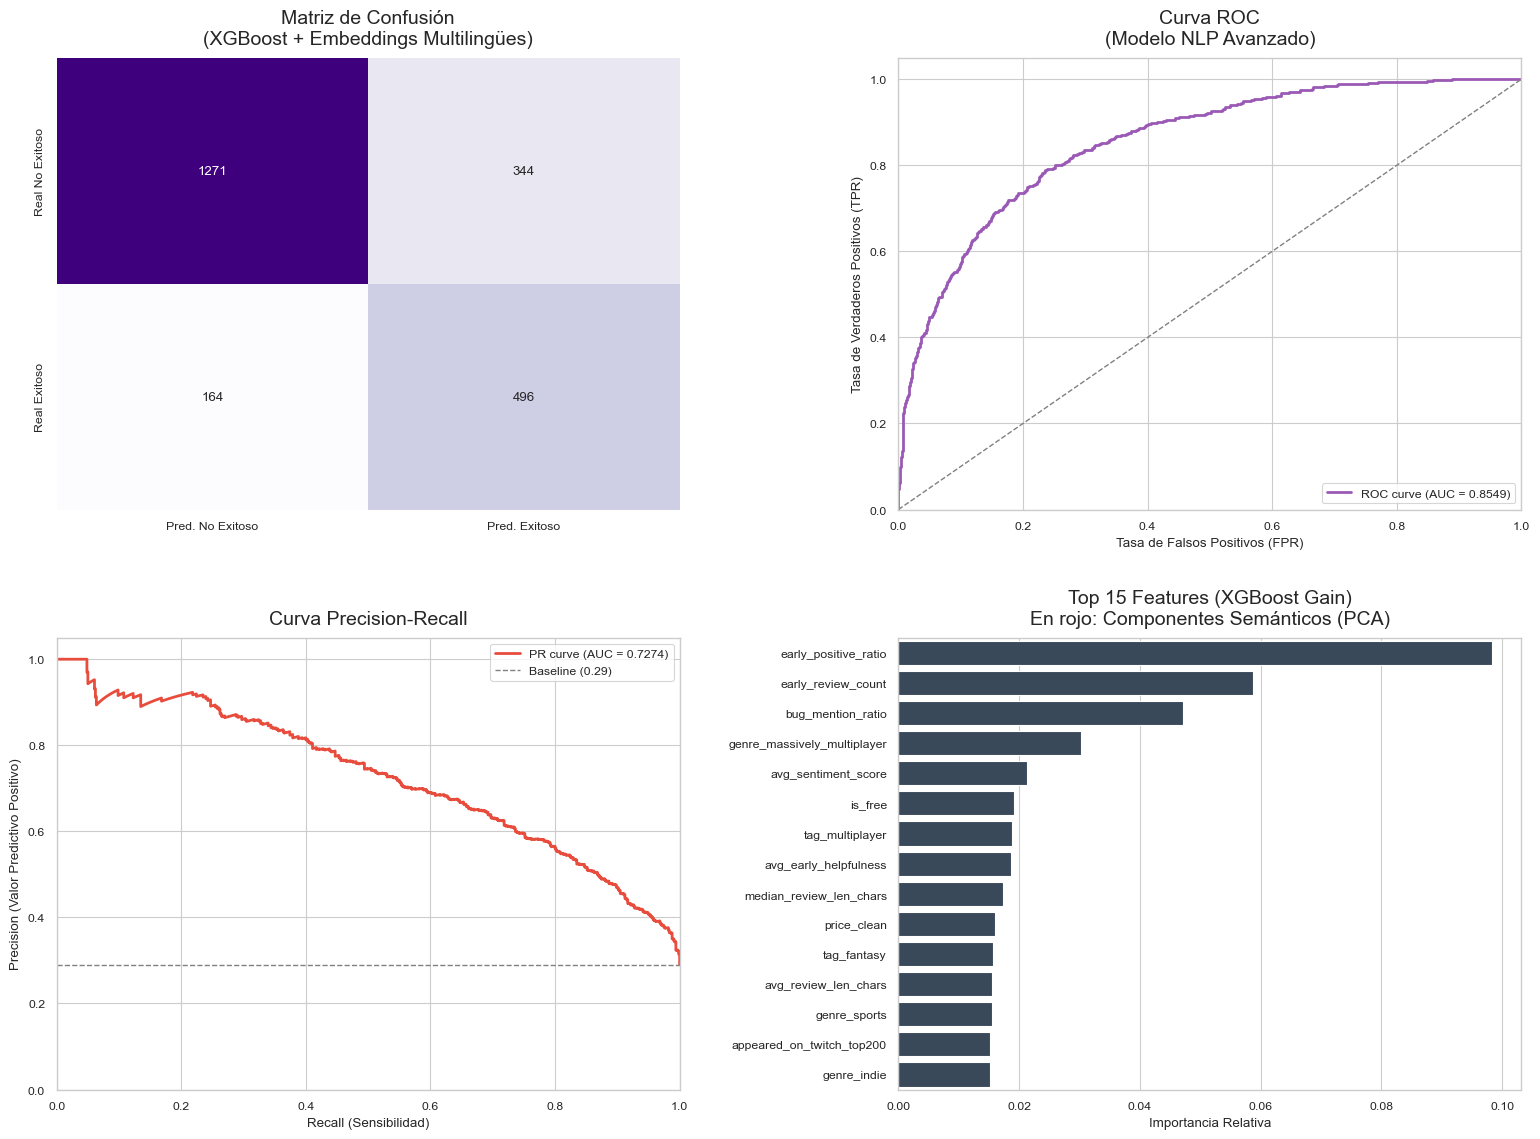

In [6]:
# ---------------------------------------------------------
# Bloque F: Visualización y Evaluación (Modelo NLP Avanzado)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, precision_recall_curve, auc, 
                             confusion_matrix)

# Configuración global
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (16, 12)
fig = plt.figure()

# 1. MATRIZ DE CONFUSIÓN
ax1 = plt.subplot(2, 2, 1)
cm = confusion_matrix(y_test_pca, y_pred_pca)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Pred. No Exitoso', 'Pred. Exitoso'],
            yticklabels=['Real No Exitoso', 'Real Exitoso'], ax=ax1)
ax1.set_title('Matriz de Confusión\n(XGBoost + Embeddings Multilingües)', fontsize=14, pad=10)

# 2. CURVA ROC
ax2 = plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(y_test_pca, y_proba_pca)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='#9b59b6', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax2.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax2.set_title('Curva ROC\n(Modelo NLP Avanzado)', fontsize=14, pad=10)
ax2.legend(loc="lower right")

# 3. CURVA PRECISION-RECALL
ax3 = plt.subplot(2, 2, 3)
precision, recall, _ = precision_recall_curve(y_test_pca, y_proba_pca)
pr_auc = auc(recall, precision)
baseline = sum(y_test_pca) / len(y_test_pca)

ax3.plot(recall, precision, color='#e74c3c', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax3.plot([0, 1], [baseline, baseline], color='gray', lw=1, linestyle='--', 
         label=f'Baseline ({baseline:.2f})')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('Recall (Sensibilidad)')
ax3.set_ylabel('Precision (Valor Predictivo Positivo)')
ax3.set_title('Curva Precision-Recall', fontsize=14, pad=10)
ax3.legend(loc="upper right")

# 4. TOP 15 FEATURE IMPORTANCE
ax4 = plt.subplot(2, 2, 4)
importances = xgb_pca.feature_importances_
df_imp = pd.DataFrame({'feature': X_train_pca.columns, 'importance': importances})
df_imp = df_imp.sort_values('importance', ascending=False).head(15)

# Resaltar en rojo los componentes PCA si entran en el top 15
colores = ['#e74c3c' if str(x).startswith('pca_') else '#34495e' for x in df_imp['feature']]

sns.barplot(x='importance', y='feature', data=df_imp, palette=colores, ax=ax4)
ax4.set_title('Top 15 Features (XGBoost Gain)\nEn rojo: Componentes Semánticos (PCA)', fontsize=14, pad=10)
ax4.set_xlabel('Importancia Relativa')
ax4.set_ylabel('')

# Ajustar espaciado y guardar
plt.tight_layout(pad=3.0)
fig_path = PROCESSED / 'xgb_nlp_advanced_dashboard.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f" Dashboard guardado exitosamente en: {fig_path}")

plt.show()


---

## Conclusiones Finales: NLP Tradicional vs. Transformers Multilingües

Para resolver la posible limitación idiomática de las herramientas heurísticas (VADER y diccionarios de bugs operan nativamente en inglés), se implementó un modelo Transformer capaz de alinear semánticamente reseñas en más de 50 idiomas (`paraphrase-multilingual-MiniLM-L12-v2`). Para evitar la maldición de la dimensionalidad, las 384 dimensiones generadas se comprimieron mediante PCA a 20 componentes principales densos.

### Resultados del Experimento
1. **Rendimiento Idéntico:** El modelo XGBoost optimizado con embeddings multilingües alcanzó un **ROC-AUC de 0.8549**, un valor prácticamente igual  frente al **0.8552** del modelo base que solo utilizaba NLP tradicional.
2. **Rechazo de Características (Feature Importance):** Al observar el gráfico de importancia de variables, **ninguno de los 20 componentes semánticos (PCA) logró entrar en el Top 15**. El algoritmo de Gradient Boosting otorgó prioridad absoluta, una vez más, al ratio de recomendación temprana, el recuento de reseñas, los problemas de software (`bug_mention_ratio`) y el modelo de negocio (`is_free`).

### Veredicto de Negocio y Arquitectura
Este experimento demuestra que **las métricas directas de tracción comunitaria y control de calidad (bugs) saturan la capacidad predictiva del texto** en el contexto del mercado de videojuegos. 

Las sutilezas semánticas profundas extraídas por redes neuronales de última generación no aportan "ganancia de información" (Information Gain) adicional para predecir el éxito comercial a medio plazo. 

Por tanto, la arquitectura recomendada es la **línea base (Notebook 04)**: utilizar NLP heurístico (conteo de palabras y VADER) resulta más eficiente en términos de coste computacional, memoria y latencia de inferencia, garantizando simultáneamente el máximo rendimiento predictivo.

---
